### Submission 2. Pre vs post stopping distance

In [33]:
%reload_ext autoreload
%autoreload 2

In [34]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTriggeredDecode, DecodeResultsLinear
from spyglass.shijiegu.changeOfMind_triggered import plot_physical_vs_mental_position, form_null_model, form_null_model_full
from spyglass.shijiegu.changeOfMind_triggered_position import load_day_position_info, return_mobility_movements, return_concentrated_hpd_moments
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.decodeQuality import hpd, return_low_hpd_time

# For 1D distance plots
from spyglass.shijiegu.changeOfMind_figures.figure4c import (return_distance_day,
    intersect_pre_post, check_nan, make_distance_plot)

# For 2D distance plots
from spyglass.shijiegu.changeOfMind_figures.figure4c import (get_position_decode_data_day,
    maze_distance, maze_distance_animal,
    plot_2D_distance_distribution, plot_2D_distance_distribution_post)

from spyglass.shijiegu.changeOfMind_figures.figure4c import make_GLM_xy, do_GLM, model2numbers

import random

In [4]:
list_of_days_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [64]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().stop_export(**paper_key, analysis_id="ephys_prepost_distance")

### First, we make the figure data used for all plots.

In [57]:
decoder_type = "run_time"
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'

success_animal_2 = {}
hpd_flag = False

for animal in ["eliot","julio"]:#["molly","klein","lewis", "eliot", "julio"]:
    data_animal = {}
    days = list_of_days_animals[animal]
    for day in days:
        data_day = get_position_decode_data_day(animal, day, decoder_type,
                                                hpd_flag = hpd_flag, do_control = True)
        data_animal[day] = data_day
    success_animal_2[animal] = True
        
    file_path = f"{output_folder}/prepost_{decoder_type}_{animal}_{hpd_flag}.pickle"
    with open(file_path, 'wb') as file:
        pickle.dump(data_animal, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")

[2026-04-24 08:50:49,663][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-24 08:50:49,673][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-24 08:50:49,706][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-24 08:50:49,713][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-24 08:50:50,687][WARNING]: Skipped checksum for file with hash: c0d8f8fa-d737-87eb-7e68-84f551cc0475, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_YQQHAWGB78.nwb
[2026-04-24 08:50:50,698][WARNING]: Skipped checksum for file with hash: c0

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_eliot_False.pickle


[2026-04-24 09:18:20,825][WARNING]: Skipped checksum for file with hash: 81c0c3a0-2beb-6a10-1510-6cf1b919c231, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_4OCXY3V6Y6.nwb
[2026-04-24 09:18:20,832][WARNING]: Skipped checksum for file with hash: 81c0c3a0-2beb-6a10-1510-6cf1b919c231, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_4OCXY3V6Y6.nwb
[2026-04-24 09:18:20,858][WARNING]: Skipped checksum for file with hash: 81c0c3a0-2beb-6a10-1510-6cf1b919c231, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_4OCXY3V6Y6.nwb
[2026-04-24 09:18:20,862][WARNING]: Skipped checksum for file with hash: 81c0c3a0-2beb-6a10-1510-6cf1b919c231, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_4OCXY3V6Y6.nwb
[2026-04-24 09:18:21,683][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-24 09:18:21,689][WARNING]: Skipped checksum for file with hash: fa

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_julio_False.pickle


In [23]:
success_animal_2

{'eliot': True, 'julio': True}

### Plotting
#### (a) decode vs location for example days.

In [5]:
decoder_type = "run_time"

In [6]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'
#hpd_flag = True
hpd_flag = False

In [31]:
def plot(position_pre, decode_pre, position_pre_control, decode_pre_control, title, ax, quantile = 0.95):
    
    gaussian_process_mean, X_train, Y_train, gaussian_process_diff = form_null_model_full(
        position_pre_control, decode_pre_control)
    
    X_query = np.linspace(0,100,100).reshape((-1,1))
    mean_prediction, _ = gaussian_process_mean.predict(X_query, return_std=True)
    std_prediction, std_prediction_std = gaussian_process_diff.predict(X_query, return_std=True)
    
    plot_physical_vs_mental_position(title, position_pre, decode_pre, color_method = 'k', save_name = None, ax = ax)

    ax.scatter(mean_prediction, X_query, label="Mean prediction",zorder=101,rasterized=True)
    ax.fill_betweenx(
        X_query.ravel(),
        mean_prediction - 6 * std_prediction,
        mean_prediction + 6 * std_prediction,
        alpha = 0.3,
        label = r"99% confidence interval",
        zorder = 102,
        color = 'teal',
        rasterized=True
    )

In [8]:
def make_figure3b(animal, days, decoder_type, hpd_flag, quantile = 0.95):
    file_path = f"{output_folder}/prepost_{decoder_type}_{animal}_{hpd_flag}.pickle"
    with open(file_path, 'rb') as file:
        loaded_data_all_days = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")
    
    position_pre, position_post = [], []
    decode_pre, decode_post =[], []
    position_pre_control, position_post_control =[],[]
    decode_pre_control, decode_post_control = [], []
    
    for day in days:
        
        load_data = loaded_data_all_days[day]
        position_pre.extend(load_data["pos_pre"])
        position_post.extend(load_data["pos_post"])
        decode_pre.extend(load_data["decode_pre"])
        decode_post.extend(load_data["decode_post"])
        position_pre_control.extend(load_data["pos_pre_control"])
        position_post_control.extend(load_data["pos_post_control"])
        decode_pre_control.extend(load_data["decode_pre_control"])
        decode_post_control.extend(load_data["decode_post_control"])

    
    fig, axes = plt.subplots(1,4,figsize=(13,5))
    plt.subplots_adjust(wspace=0.25)
    
    """ pre control"""
    title = f"Rat {animal[0].upper()} previous non-com trial \n outbound"
    plot(position_pre_control, decode_pre_control,
        position_pre_control, decode_pre_control, title, ax = axes[0], quantile = quantile)
    
    """ pre """
    title = f"Rat {animal[0].upper()} com trial \n pre stopping"
    plot(position_pre, decode_pre,
        position_pre_control, decode_pre_control, title, ax = axes[1], quantile = quantile)
        
    """ post """  
    title = f"Rat {animal[0].upper()} com trial \n post stopping"
    plot(position_post, decode_post,
        position_post_control, decode_post_control, title, ax = axes[2], quantile = quantile)

    """ post """  
    title = f"Rat {animal[0].upper()} previous non-com trial \n inbound"
    plot(position_post_control, decode_post_control,
        position_post_control, decode_post_control, title, ax = axes[3], quantile = quantile)
    
    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_prepost_{animal[0].upper()}.pdf"
    fig.savefig(file_path, format="pdf", bbox_inches="tight")

    return position_post_control, decode_post_control

In [ ]:
# debug

In [60]:
file_path = f"{output_folder}/prepost_{decoder_type}_{animal}_{hpd_flag}.pickle"
with open(file_path, 'rb') as file:
    loaded_data_all_days = pickle.load(file)
    print(f"Data successfully loaded from {file_path}")

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_eliot_False.pickle


In [61]:
load_data = loaded_data_all_days["20221020"]

In [62]:
len(load_data["pos_pre"])

44

In [63]:
len(load_data["pos_pre_control"])

45

In [ ]:
# end debug

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_eliot_False.pickle


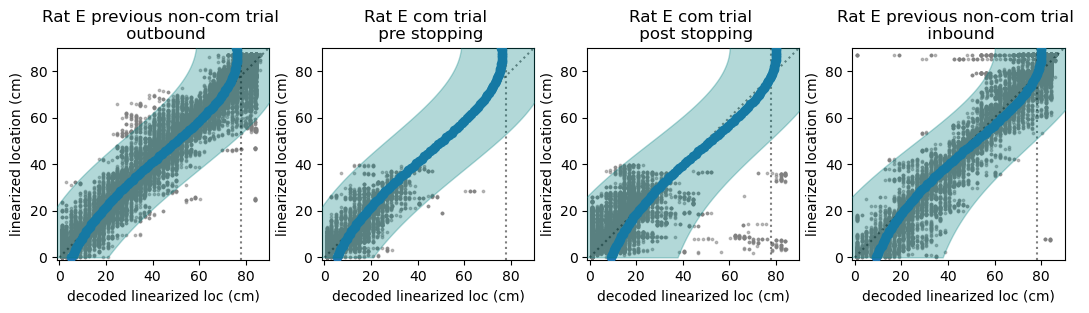

In [59]:
animal = "eliot"
days = ["20221020"]
position_post_control, decode_post_control = make_figure3b(animal, days, decoder_type, hpd_flag)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_julio_False.pickle


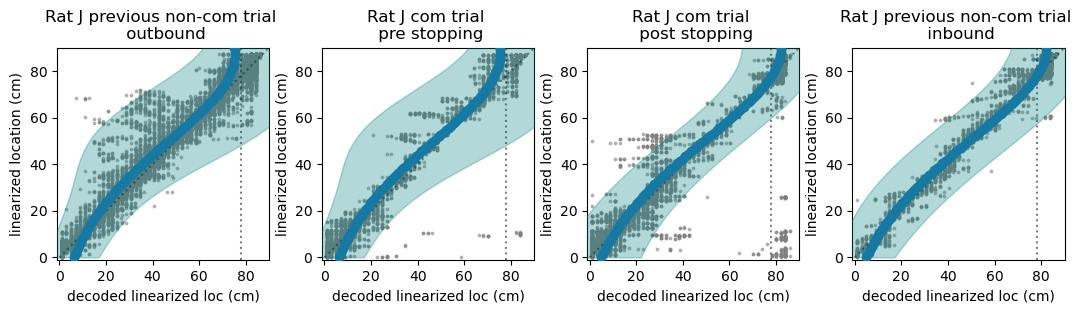

In [25]:
animal = "julio"
days = ['20230805','20230806']
position_post_control, decode_post_control = make_figure3b(animal, days, decoder_type, hpd_flag)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_lewis_False.pickle


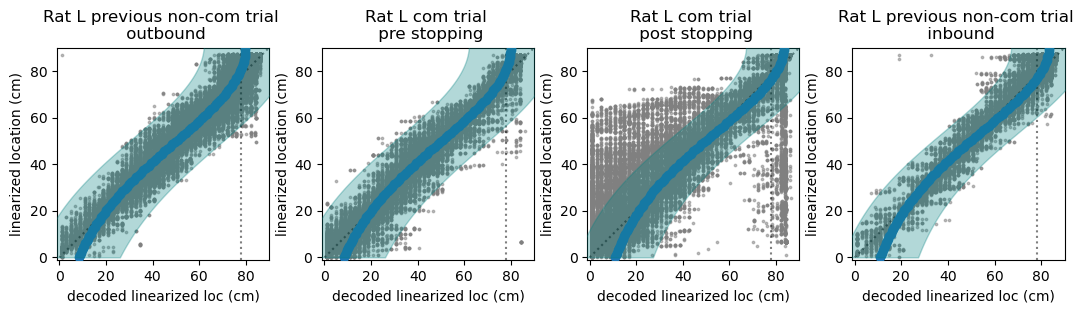

In [10]:
animal = "lewis"
days = ['20240108','20240109']
position_post_control, decode_post_control = make_figure3b(animal, days, decoder_type, hpd_flag)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_klein_False.pickle


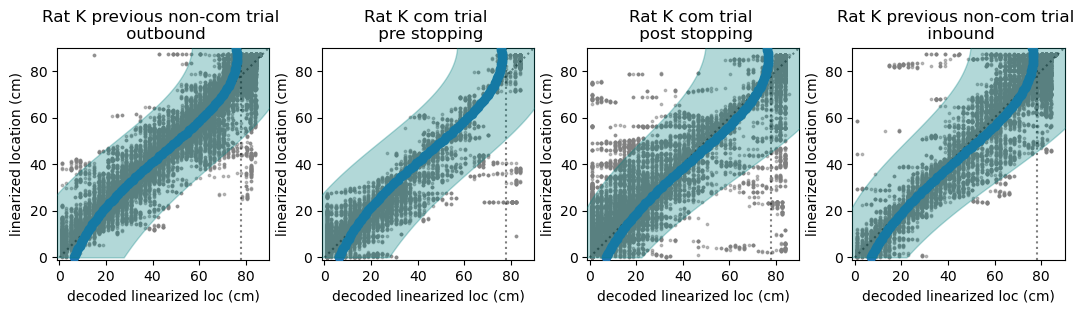

In [11]:
animal = "klein"
days = ['20231107','20231108']
position_post_control, decode_post_control = make_figure3b(animal, days, decoder_type, hpd_flag, quantile = 0.98)

## 2D distance

In [14]:
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_session_spyglass


In [15]:
success = {}
for animal in ["molly","eliot", "klein", "lewis"]:#["eliot", "julio", "klein", "lewis"]:
    d_pre, d_post = maze_distance_animal(animal, list_of_days_animals[animal])
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'
    file_path = f"{output_folder}/prepost_2D_{animal}.pickle"
    data = {"d_pre": d_pre, "d_post": d_post}
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    success[animal] = 1

molly20220415_.nwb
No triggered decode found for  {'nwb_file_name': 'molly20220415_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220415_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220415_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220415_.nwb', 'epoch': 8, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
molly20220416_.nwb
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly2

[2026-04-23 13:06:15,533][WARNING]: Skipped checksum for file with hash: 039acaf2-b93a-01f8-b88a-74010c1d5c28, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_RLS96PKWQ9.nwb
[2026-04-23 13:06:24,991][WARNING]: Skipped checksum for file with hash: ad94c9c8-0ecc-8760-07a4-ee55304aa8f9, and path: /stelmo/nwb/analysis/molly20220416_DULQT5SPZL.nwb
[2026-04-23 13:06:25,004][WARNING]: Skipped checksum for file with hash: ad94c9c8-0ecc-8760-07a4-ee55304aa8f9, and path: /stelmo/nwb/analysis/molly20220416_DULQT5SPZL.nwb
[2026-04-23 13:06:25,015][WARNING]: Skipped checksum for file with hash: ad94c9c8-0ecc-8760-07a4-ee55304aa8f9, and path: /stelmo/nwb/analysis/molly20220416_DULQT5SPZL.nwb
[2026-04-23 13:06:25,021][WARNING]: Skipped checksum for file with hash: ad94c9c8-0ecc-8760-07a4-ee55304aa8f9, and path: /stelmo/nwb/analysis/molly20220416_DULQT5SPZL.nwb
[2026-04-23 13:06:34,306][WARNING]: Skipped checksum for file with hash: 40b07149-ae6f-e91a-3635-368d50f45f16, and path: /stelmo/nw

No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 10, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
molly20220417_.nwb


[2026-04-23 13:06:43,175][WARNING]: Skipped checksum for file with hash: 7147670f-da95-1a6d-4489-953d8e01234e, and path: /stelmo/nwb/analysis/molly20220417_MKCTX3POQC.nwb
[2026-04-23 13:06:43,187][WARNING]: Skipped checksum for file with hash: 7147670f-da95-1a6d-4489-953d8e01234e, and path: /stelmo/nwb/analysis/molly20220417_MKCTX3POQC.nwb
[2026-04-23 13:06:43,196][WARNING]: Skipped checksum for file with hash: 7147670f-da95-1a6d-4489-953d8e01234e, and path: /stelmo/nwb/analysis/molly20220417_MKCTX3POQC.nwb
[2026-04-23 13:06:43,201][WARNING]: Skipped checksum for file with hash: 7147670f-da95-1a6d-4489-953d8e01234e, and path: /stelmo/nwb/analysis/molly20220417_MKCTX3POQC.nwb
[2026-04-23 13:06:52,801][WARNING]: Skipped checksum for file with hash: c0591f47-c3f0-2a9f-0323-0fe93e973198, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_BZK7V72DS4.nwb
[2026-04-23 13:07:01,823][WARNING]: Skipped checksum for file with hash: 5c14bc3a-6d13-7a00-e158-1933a8fe3f0b, and path: /stelmo/nw

molly20220418_.nwb


[2026-04-23 13:08:15,589][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2026-04-23 13:08:15,601][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2026-04-23 13:08:15,611][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2026-04-23 13:08:15,617][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2026-04-23 13:08:24,957][WARNING]: Skipped checksum for file with hash: 1cecc6f2-d20c-e894-4987-2f4bbae65c42, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_5IQ43UCN08.nwb
[2026-04-23 13:08:33,980][WARNING]: Skipped checksum for file with hash: 08c5798e-60e4-2aea-0743-1f40f1959ac3, and path: /stelmo/nw

molly20220419_.nwb


[2026-04-23 13:09:48,089][WARNING]: Skipped checksum for file with hash: 5f1e0394-52bf-2713-1252-60def153097b, and path: /stelmo/nwb/analysis/molly20220419_BL0OZ44F19.nwb
[2026-04-23 13:09:48,099][WARNING]: Skipped checksum for file with hash: 5f1e0394-52bf-2713-1252-60def153097b, and path: /stelmo/nwb/analysis/molly20220419_BL0OZ44F19.nwb
[2026-04-23 13:09:48,108][WARNING]: Skipped checksum for file with hash: 5f1e0394-52bf-2713-1252-60def153097b, and path: /stelmo/nwb/analysis/molly20220419_BL0OZ44F19.nwb
[2026-04-23 13:09:48,113][WARNING]: Skipped checksum for file with hash: 5f1e0394-52bf-2713-1252-60def153097b, and path: /stelmo/nwb/analysis/molly20220419_BL0OZ44F19.nwb
[2026-04-23 13:09:57,484][WARNING]: Skipped checksum for file with hash: c7883357-9622-653a-c02d-33ab760a8a73, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_X5XTC75H39.nwb
[2026-04-23 13:10:06,577][WARNING]: Skipped checksum for file with hash: 2a53992d-2b2c-5110-a7cf-8f232d106a4f, and path: /stelmo/nw

In [119]:
success

{'molly': 1}

Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_molly.pickle
molly: p value:  1.4835782937655236e-13
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_eliot.pickle
eliot: p value:  8.409236977766122e-21
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_julio.pickle
julio: p value:  0.00032439113497057193
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_klein.pickle
klein: p value:  8.204755418143657e-21
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_lewis.pickle
lewis: p value:  8.835192924145674e-43
5.115 0.03
5.115 0.03
5.115 0.03
5.115 0.03
5.115 0.03


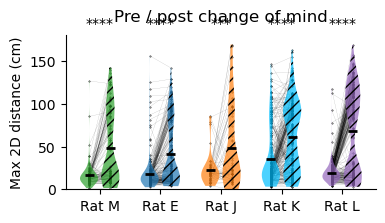

In [54]:
animals = ["molly","eliot","julio","klein","lewis"] #"julio", "klein", "lewis"]
plot_2D_distance_distribution(animals, param = "com",
                              savename = "prepost_2D_distance_distribution")

In [129]:
### for run through trials
success = {}
for animal in ["eliot","julio", "molly", "lewis"]:
    d_pre, d_post = maze_distance_animal(animal, list_of_days_animals[animal],
                                        param = "params_both_control_max_run_time_2_state",
                                        speed_threshold = 4)
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'
    file_path = f"{output_folder}/prepost_2D_{animal}_control.pickle"
    data = {"d_pre": d_pre, "d_post": d_post}
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    success[animal] = 1

[2026-04-05 12:24:09,506][WARNING]: Skipped checksum for file with hash: 5ef05bc0-8b18-5b01-c847-014e41f564bf, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_T21A6Q4QCQ.nwb


eliot20221018_.nwb


[2026-04-05 12:24:14,931][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-05 12:24:14,943][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-05 12:24:14,953][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-05 12:24:14,960][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-05 12:24:15,115][WARNING]: Skipped checksum for file with hash: 65b81c5d-df7f-c3ba-c68e-04fd1d13ddec, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_U3NWG5FCGC.nwb


No triggered decode found for  {'nwb_file_name': 'eliot20221018_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}


[2026-04-05 12:24:20,201][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-05 12:24:20,210][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-05 12:24:20,221][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-05 12:24:20,226][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-05 12:24:20,326][WARNING]: Skipped checksum for file with hash: b01fdc61-5b8e-a165-4bb0-d6079059358e, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_T9CX77Y8PM.nwb
[2026-04-05 12:24:25,374][WARNING]: Skipped checksum for file with hash: a2

...

lewis20240109_.nwb


[2026-04-05 12:39:10,107][WARNING]: Skipped checksum for file with hash: 49e3a756-1b1e-a323-44d1-1d9acf2a555d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_P8WG36Z229.nwb
[2026-04-05 12:39:10,115][WARNING]: Skipped checksum for file with hash: 49e3a756-1b1e-a323-44d1-1d9acf2a555d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_P8WG36Z229.nwb
[2026-04-05 12:39:10,122][WARNING]: Skipped checksum for file with hash: 49e3a756-1b1e-a323-44d1-1d9acf2a555d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_P8WG36Z229.nwb
[2026-04-05 12:39:10,126][WARNING]: Skipped checksum for file with hash: 49e3a756-1b1e-a323-44d1-1d9acf2a555d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_P8WG36Z229.nwb
[2026-04-05 12:39:10,485][WARNING]: Skipped checksum for file with hash: 65a37398-7b35-8b8b-81ee-f0ff93161231, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_CLWSZFXLUK.nwb
[2026-04-05 12:39:19,388][WARNING]: Skipped checksum for file with hash: d8

lewis20240110_.nwb


[2026-04-05 12:39:47,190][WARNING]: Skipped checksum for file with hash: 41cb5ffa-a716-3f45-deb0-3dd332e584ba, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_K3L1N7YDZ9.nwb
[2026-04-05 12:39:47,200][WARNING]: Skipped checksum for file with hash: 41cb5ffa-a716-3f45-deb0-3dd332e584ba, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_K3L1N7YDZ9.nwb
[2026-04-05 12:39:47,210][WARNING]: Skipped checksum for file with hash: 41cb5ffa-a716-3f45-deb0-3dd332e584ba, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_K3L1N7YDZ9.nwb
[2026-04-05 12:39:47,216][WARNING]: Skipped checksum for file with hash: 41cb5ffa-a716-3f45-deb0-3dd332e584ba, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_K3L1N7YDZ9.nwb
[2026-04-05 12:39:47,546][WARNING]: Skipped checksum for file with hash: 735b04c0-3f68-df6b-4ae9-151de1080b48, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_X1CSHLKERN.nwb
[2026-04-05 12:39:56,471][WARNING]: Skipped checksum for file with hash: 7c

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_lewis_control.pickle


In [127]:
#%debug

Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_molly_control.pickle
molly: p value:  0.9530739988663192
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_eliot_control.pickle
eliot: p value:  0.999995430794278
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_julio_control.pickle
julio: p value:  0.9999355566788417
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_klein_control.pickle
klein: p value:  0.9999074205427524
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_lewis_control.pickle
lewis: p value:  1.0


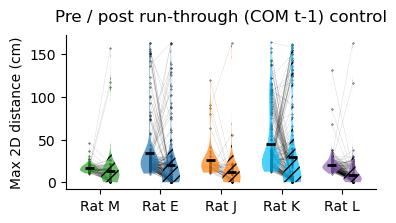

In [51]:
animals = ["molly","eliot","julio", "klein", "lewis"]
plot_2D_distance_distribution(animals, param = "control",
                              savename = "prepost_2D_distance_distribution_control")

#### (b) distance plot

In [16]:
import seaborn as sns
from scipy.stats import ranksums
from scipy.stats import ttest_rel
from spyglass.shijiegu.changeOfMind import color_by_rat
import starbars
diff_pre, diff_post, diff_pre_control, diff_post_control = {}, {}, {}, {}


In [35]:
for animal in ["molly","lewis", "eliot", "klein", "julio"]:
    days = list_of_days_animals[animal]
    (diff_pre[animal], diff_post[animal],
     diff_pre_control[animal], diff_post_control[animal]) = make_distance_plot(
        animal, days, hpd_flag = False,
         output_folder = output_folder, decoder_type = decoder_type)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_molly_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_lewis_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_eliot_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_klein_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_julio_False.pickle


### 1. Comparing pre and post

molly: p value:  5.109990883157945e-09
eliot: p value:  4.949871447210322e-12
klein: p value:  1.5546571493862627e-14
julio: p value:  3.693134260251284e-06
lewis: p value:  1.5372666485422343e-29
5.060000000000001 0.03
5.060000000000001 0.03
5.060000000000001 0.03
5.060000000000001 0.03
5.060000000000001 0.03


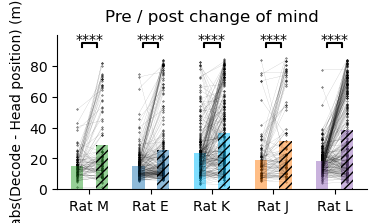

In [36]:
fig, axes = plt.subplots(1,1, figsize=(4, 2))

animals = ["molly","eliot", "klein", "julio","lewis"]

ax = axes
animal_ind = 0
annotations = []
for animal in animals:
    
    pre, post, pre_control, post_control = diff_pre[animal], diff_post[animal], diff_pre_control[animal], diff_post_control[animal]
    
    # mean estmate
    pre_mean, post_mean, pre_control_mean, post_control_mean = np.nanmean(pre), np.nanmean(post), np.nanmean(pre_control), np.nanmean(post_control)

    # std
    pre_sd, post_sd, pre_control_sd, post_control_sd = np.nanstd(pre), np.nanstd(post), np.nanstd(pre_control), np.nanstd(post_control)
    
    xs = np.array([0,0.4]) + (animal_ind)
    all_data = [pre, post]

    # all pairs
    for ind in range(len(pre)):
        ax.scatter(xs, [pre[ind], post[ind]], color = 'k', s = 0.1)
        ax.plot(xs, [pre[ind], post[ind]], color = 'k', linewidth = 0.1, alpha = 0.5)

    # mean and sd
    ax.bar(xs, [pre_mean, post_mean], width=0.2, hatch=['', '////'], alpha = 0.5, color = color_by_rat[animal])
    
    ax.set_ylabel("abs(Decode - Head position) (m)")

    # stats tests
    for pairs in [(pre, post, 0+animal_ind, 0.4+animal_ind)]:
        
        x, y = pairs[0], pairs[1]
        loc_x, loc_y = pairs[2], pairs[3]
        _, p_value = ttest_rel(x, y, alternative = "less")
        print(f"{animal}: p value: ",p_value)
        if p_value < 0.05:
            annotations.append((loc_x, loc_y, np.round(p_value, 4)))

    animal_ind += 1
    
starbars.draw_annotation(annotations, ax = ax)
ax.set_xticks(np.arange(animal_ind) + 0.2)
ax.set_xticklabels([f"Rat {animal[0].upper()}" for animal in animals])
ax.set_title("Pre / post change of mind", pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_prepost_abs_summary.pdf"
#fig.savefig(file_path, format="pdf", bbox_inches="tight")

#### mixed linear model

In [293]:
from spyglass.shijiegu.changeOfMind_figures.figure4c import make_GLM_xy, do_GLM, model2numbers

In [37]:
animals = ["molly","eliot", "klein", "julio","lewis"]

GLM_xy = make_GLM_xy(animals, diff_pre, diff_post)
result, y, X = do_GLM(animals, GLM_xy, "pre", "post")
params, coef_names, coef_est, pvalues, CI = model2numbers(result)

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     65.07
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.24e-62
Time:                        21:08:16   Log-Likelihood:                -7995.9
No. Observations:                1824   AIC:                         1.600e+04
Df Residuals:                    1818   BIC:                         1.604e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Rat M          3.8394      1.1

### 2. Comparing control pre and pre

In [38]:
def std_err(x):
    x = x[~np.isnan(x)]
    return np.nanstd(x)/np.sqrt(len(x))

molly: p value:  5.910819572964827e-06
eliot: p value:  0.0016688288105408727
julio: p value:  0.0036316806135612304
klein: p value:  2.9603322020424054e-09
lewis: p value:  4.150178933027624e-07
5.170000000000001 0.03
5.170000000000001 0.03
5.170000000000001 0.03
5.170000000000001 0.03
5.170000000000001 0.03


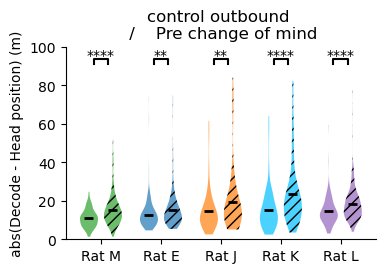

In [50]:
fig, axes = plt.subplots(1,1, figsize=(4, 2.5))

animals = ["molly","eliot", "julio", "klein","lewis"] #julio

ax = axes
animal_ind = 0
dx = 0.4
annotations = []
for animal in animals:
    
    pre, post, pre_control, post_control = diff_pre[animal], diff_post[animal], diff_pre_control[animal], diff_post_control[animal]
    
    # mean estmate
    pre_mean, post_mean, pre_control_mean, post_control_mean = np.nanmean(pre), np.nanmean(post), np.nanmean(pre_control), np.nanmean(post_control)

    # std
    pre_sd, post_sd, pre_control_sd, post_control_sd = std_err(pre), std_err(post), std_err(pre_control), std_err(post_control)
    
    xs = np.array([0,0.4]) + (animal_ind)
    all_data = [pre, pre_control]

    # mean and sd
    pre = pre[~np.isnan(pre)]
    pre_control = pre_control[~np.isnan(pre_control)]
    parts_pre = ax.violinplot([pre_control], positions=[animal_ind], widths=0.3,
                                    showmeans=True, showextrema=False)
    parts_post = ax.violinplot([pre], positions=[animal_ind + dx], widths=0.3,
                                     showmeans=True, showextrema=False)
    for pc in parts_pre['bodies']:
            pc.set_facecolor(color_by_rat[animal])
            pc.set_edgecolor('none')
            pc.set_alpha(0.7)
            pc.set_zorder(1)
    for pc in parts_post['bodies']:
            pc.set_facecolor(color_by_rat[animal])
            pc.set_edgecolor('none')
            pc.set_alpha(0.7)
            pc.set_hatch("///")
            pc.set_zorder(1)
    parts_pre['cmeans'].set_linewidth(2)
    parts_pre['cmeans'].set_edgecolor('black')
    parts_post['cmeans'].set_linewidth(2)
    parts_post['cmeans'].set_edgecolor('black')
            
    #ax.bar(xs, [pre_mean, pre_control_mean], yerr=[pre_sd, pre_control_sd], width=0.35, hatch=['', '////'], color = color_by_rat[animal])
    
    ax.set_ylabel("abs(Decode - Head position) (m)")

    # stats tests
    for pairs in [(pre_control, pre, 0+animal_ind, dx+animal_ind)]:
        
        x, y = pairs[0], pairs[1]
        x = x[~np.isnan(x)]
        y = y[~np.isnan(y)]
        loc_x, loc_y = pairs[2], pairs[3]
        _, p_value = ranksums(x, y, alternative = "less")
        print(f"{animal}: p value: ",p_value)
        if p_value < 0.05:
            annotations.append((loc_x, loc_y, np.round(p_value, 4)))

    animal_ind += 1
    
starbars.draw_annotation(annotations, ax = ax)
ax.set_xticks(np.arange(animal_ind) + 0.2)
ax.set_xticklabels([f"Rat {animal[0].upper()}" for animal in animals])
ax.set_title("control outbound \n /    Pre change of mind")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
axes.set_ylim(0, 100) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_pre_pre_control_abs_summary.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [40]:
animals = ["molly","eliot", "klein", "julio","lewis"]

GLM_xy = make_GLM_xy(animals, diff_pre, diff_pre_control)
result, y, X = do_GLM(animals, GLM_xy, "pre", "pre control")
params, coef_names, coef_est, pvalues, CI = model2numbers(result)

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     34.03
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           3.79e-33
Time:                        21:08:34   Log-Likelihood:                -6175.5
No. Observations:                1630   AIC:                         1.236e+04
Df Residuals:                    1624   BIC:                         1.240e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Rat M           1.5957      

### 3. post and post control

### 2D

In [30]:
### for run through trials
success = {}

for animal in ["eliot", "lewis", "julio"]:#["eliot","julio", "molly", "lewis","klein"]:

    # ========= Find out about the range =========
    file_path = f"{output_folder}/prepost_{decoder_type}_{animal}_{hpd_flag}.pickle"
    with open(file_path, 'rb') as file:
        loaded_data_all_days = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    days = list_of_days_animals[animal]
    
    position_post = []
    for day in days:
        load_data = loaded_data_all_days[day]
        position_post.extend(load_data["pos_post"])

    pos_range = [[np.nanmin(pos), np.nanmax(pos)] for pos in position_post]
        
    d_pre, d_post = maze_distance_animal(animal, list_of_days_animals[animal],
                                        param = "params_both_control_max_run_time_2_state",
                                        speed_threshold = 4, fix_range = pos_range)

    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'
    file_path = f"{output_folder}/post_2D_{animal}_control.pickle"
    data = {"d_pre": d_pre, "d_post": d_post}
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    success[animal] = 1

[2026-04-23 20:52:53,864][WARNING]: Skipped checksum for file with hash: da086407-6f25-2a70-61fb-2d0115c0592c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_FMH9RLO3N3.nwb


Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_eliot_False.pickle
eliot20221018_.nwb


[2026-04-23 20:52:59,103][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-23 20:52:59,111][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-23 20:52:59,119][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-23 20:52:59,123][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-23 20:52:59,244][WARNING]: Skipped checksum for file with hash: 9a98dff7-cce1-d0bf-2cd8-c48b7ff7321f, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_W7HBGBPEDL.nwb


No triggered decode found for  {'nwb_file_name': 'eliot20221018_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}


[2026-04-23 20:53:04,342][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-23 20:53:04,350][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-23 20:53:04,357][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-23 20:53:04,361][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-23 20:53:04,458][WARNING]: Skipped checksum for file with hash: 8e0f47ce-2dc7-b96a-da83-b8597446c73f, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_91JVZ6KLGV.nwb
[2026-04-23 20:53:09,587][WARNING]: Skipped checksum for file with hash: a2

...

julio20230810_.nwb
No triggered decode found for  {'nwb_file_name': 'julio20230810_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}


[2026-04-23 21:06:07,609][WARNING]: Skipped checksum for file with hash: d0d3688c-340a-4609-faee-0c3be27e0e33, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_N140AAB36C.nwb
[2026-04-23 21:06:07,618][WARNING]: Skipped checksum for file with hash: d0d3688c-340a-4609-faee-0c3be27e0e33, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_N140AAB36C.nwb
[2026-04-23 21:06:07,625][WARNING]: Skipped checksum for file with hash: d0d3688c-340a-4609-faee-0c3be27e0e33, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_N140AAB36C.nwb
[2026-04-23 21:06:07,629][WARNING]: Skipped checksum for file with hash: d0d3688c-340a-4609-faee-0c3be27e0e33, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_N140AAB36C.nwb
[2026-04-23 21:06:07,808][WARNING]: Skipped checksum for file with hash: daf778c7-8894-4494-db50-e166f74b09a8, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_4MHYMUGWIV.nwb


No triggered decode found for  {'nwb_file_name': 'julio20230810_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230810_.nwb', 'epoch': 8, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}
julio20230811_.nwb
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}


[2026-04-23 21:06:16,776][WARNING]: Skipped checksum for file with hash: 74345efc-888c-6730-f303-766e98bcecc9, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_058DFJQE11.nwb
[2026-04-23 21:06:16,783][WARNING]: Skipped checksum for file with hash: 74345efc-888c-6730-f303-766e98bcecc9, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_058DFJQE11.nwb
[2026-04-23 21:06:16,790][WARNING]: Skipped checksum for file with hash: 74345efc-888c-6730-f303-766e98bcecc9, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_058DFJQE11.nwb
[2026-04-23 21:06:16,795][WARNING]: Skipped checksum for file with hash: 74345efc-888c-6730-f303-766e98bcecc9, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_058DFJQE11.nwb


No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 9, 'proportion': 0.1, 'parameter': 'params_both_control_max_run_time_2_state'}
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/post_2D_julio_control.pickle


Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_molly.pickle
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/post_2D_molly_control.pickle
molly: p value:  5.690412472959304e-07
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_eliot.pickle
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/post_2D_eliot_control.pickle
eliot: p value:  0.31886979922241376
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_julio.pickle
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/post_2D_julio_control.pickle
julio: p value:  1.0315447252995919e-06
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_2D_klein.pickle
Data successfully loaded data from /stelmo/shijie/change_of_mind_analysis/figure4/post_2D_klein_control.pickle
klein: p value: 

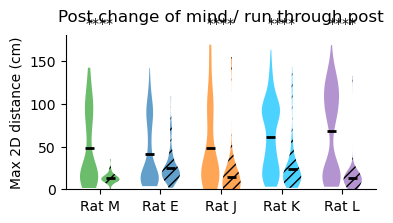

In [45]:
animals = ["molly","eliot","julio", "klein", "lewis"]
d_post_com_animals, d_post_com_control_animals = plot_2D_distance_distribution_post(animals,
                              savename = "postpost_2D_distance_distribution_control")

In [46]:
animals = ["molly","eliot", "klein", "julio","lewis"]

GLM_xy = make_GLM_xy(animals, d_post_com_animals, d_post_com_control_animals)
result, y, X = do_GLM(animals, GLM_xy, "post", "post control")
params, coef_names, coef_est, pvalues, CI = model2numbers(result)

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     49.11
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.80e-46
Time:                        21:17:01   Log-Likelihood:                -6321.1
No. Observations:                1244   AIC:                         1.265e+04
Df Residuals:                    1238   BIC:                         1.268e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Rat M            5.1497   

### 1D

molly: p value:  8.064263547959747e-05
eliot: p value:  0.9323666914250168
klein: p value:  5.608178479747963e-08
julio: p value:  0.0042866316226925286
lewis: p value:  2.7654099159741513e-08
5.170000000000001 0.03
5.170000000000001 0.03
5.170000000000001 0.03
5.170000000000001 0.03


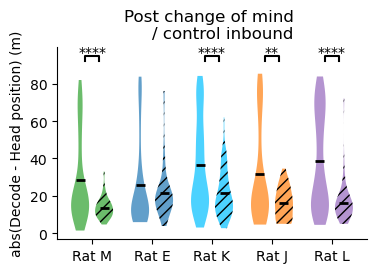

In [49]:
fig, axes = plt.subplots(1,1, figsize=(4, 2.5))

animals = ["molly","eliot", "klein", "julio","lewis"]

ax = axes
animal_ind = 0
annotations = []
for animal in animals:
    
    pre, post, pre_control, post_control = diff_pre[animal], diff_post[animal], diff_pre_control[animal], diff_post_control[animal]
    post_control = post_control[~np.isnan(post_control)]
    post = post[~np.isnan(post)]
    
    # mean estmate
    pre_mean, post_mean, pre_control_mean, post_control_mean = np.nanmean(pre), np.nanmean(post), np.nanmean(pre_control), np.nanmean(post_control)

    # std
    pre_sd, post_sd, pre_control_sd, post_control_sd = std_err(pre), std_err(post), std_err(pre_control), std_err(post_control)
    
    xs = np.array([0,0.4]) + (animal_ind)
    all_data = [post, post_control]
    post = post[~np.isnan(post)]
    post_control = post_control[~np.isnan(post_control)]
    
    parts_pre = ax.violinplot([post], positions=[animal_ind], widths=0.3,
                                    showmeans=True, showextrema=False)
    parts_post = ax.violinplot([post_control], positions=[animal_ind + dx], widths=0.3,
                                     showmeans=True, showextrema=False)
    for pc in parts_pre['bodies']:
            pc.set_facecolor(color_by_rat[animal])
            pc.set_edgecolor('none')
            pc.set_alpha(0.7)
            pc.set_zorder(1)
    for pc in parts_post['bodies']:
            pc.set_facecolor(color_by_rat[animal])
            pc.set_edgecolor('none')
            pc.set_alpha(0.7)
            pc.set_hatch("///")
            pc.set_zorder(1)
    parts_pre['cmeans'].set_linewidth(2)
    parts_pre['cmeans'].set_edgecolor('black')
    parts_post['cmeans'].set_linewidth(2)
    parts_post['cmeans'].set_edgecolor('black')

    # mean and sd
    # ax.bar(xs, [post_mean, post_control_mean], yerr=[post_sd, post_control_sd], width=0.35, hatch=['', '////'], color = color_by_rat[animal])
    
    ax.set_ylabel("abs(Decode - Head position) (m)")

    # stats tests
    for pairs in [(post, post_control, 0+animal_ind, 0.4+animal_ind)]:
        
        x, y = pairs[0], pairs[1]
        x = x[~np.isnan(x)]
        y = y[~np.isnan(y)]
        loc_x, loc_y = pairs[2], pairs[3]
        _, p_value = ranksums(x, y, alternative = "greater")
        print(f"{animal}: p value: ",p_value)
        if p_value < 0.05:
            annotations.append((loc_x, loc_y, np.round(p_value, 4)))

    animal_ind += 1
    
#ax.set_ylim(0, 180) 
starbars.draw_annotation(annotations, ax = ax)
ax.set_xticks(np.arange(animal_ind) + 0.2)
ax.set_xticklabels([f"Rat {animal[0].upper()}" for animal in animals])
ax.set_title("Post change of mind \n    / control inbound")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_post_post_control_abs_summary.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [299]:
animals = ["molly","eliot", "klein", "julio","lewis"]

GLM_xy = make_GLM_xy(animals, diff_post, diff_post_control)
result, y, X = do_GLM(animals, GLM_xy, "post", "post control")
params, coef_names, coef_est, pvalues, CI = model2numbers(result)

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     40.23
Date:                Tue, 20 Jan 2026   Prob (F-statistic):           2.22e-39
Time:                        08:56:23   Log-Likelihood:                -8423.3
No. Observations:                1865   AIC:                         1.686e+04
Df Residuals:                    1859   BIC:                         1.689e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Rat M            6.3744   